In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    root_mean_squared_error,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    roc_curve,
    r2_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
)

In [2]:
world_bank = pd.read_parquet("../data/Merged/final_merged_panel.parquet")

In [3]:
world_bank["recession"].value_counts()

recession
0    11988
1      727
Name: count, dtype: int64

## Regression

In [37]:
world_bank.columns

Index(['country', 'year', 'wb_current_account_pct_gdp', 'wb_exports_pct_gdp',
       'wb_gdp_growth', 'wb_gov_consumption_pct_gdp', 'wb_imports_pct_gdp',
       'wb_inflation_cpi', 'imf_inflation_imf', 'non_null_feature_count',
       'feature_coverage_pct', 'wb_current_account_pct_gdp_lag1',
       'wb_current_account_pct_gdp_lag2', 'wb_exports_pct_gdp_lag1',
       'wb_exports_pct_gdp_lag2', 'wb_gdp_growth_lag1', 'wb_gdp_growth_lag2',
       'wb_gov_consumption_pct_gdp_lag1', 'wb_gov_consumption_pct_gdp_lag2',
       'wb_imports_pct_gdp_lag1', 'wb_imports_pct_gdp_lag2',
       'wb_inflation_cpi_lag1', 'wb_inflation_cpi_lag2',
       'imf_inflation_imf_lag1', 'imf_inflation_imf_lag2',
       'wb_current_account_pct_gdp_chg1', 'wb_exports_pct_gdp_chg1',
       'wb_gdp_growth_chg1', 'wb_gov_consumption_pct_gdp_chg1',
       'wb_imports_pct_gdp_chg1', 'wb_inflation_cpi_chg1',
       'imf_inflation_imf_chg1', 'recession'],
      dtype='str')

In [ ]:
y = world_bank["wb_gdp_growth"]
X = world_bank.drop(
    columns=["wb_gdp_growth", "recession", "year", "wb_gdp_growth_chg1"]
)
X = pd.get_dummies(X, columns=["country"], drop_first=True)

# Val-test split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

# Train-val split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=123
)

In [ ]:
xgb_mod = XGBRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=123,
    eval_metrics="rmse",
)

xgb_mod.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = xgb_mod.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-Squared:", r2_score(y_test, y_pred))

# xgb.plot_importance(xgb_mod)

/Users/gauravlaw/Desktop/Machine Learning/SP26_IDS705_ML_Project/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:20:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RMSE: 5.236709164481967
R²: 0.22151607403601736


In [41]:
# Get feature importances
importance_df = pd.DataFrame(
    {
        "feature": xgb_mod.get_booster().feature_names,
        "importance": xgb_mod.feature_importances_,
    }
).sort_values("importance", ascending=False)

# Option 1: Drop country dummies entirely, keep only real features
importance_df_clean = importance_df[
    ~importance_df["feature"].str.startswith("country_")
]

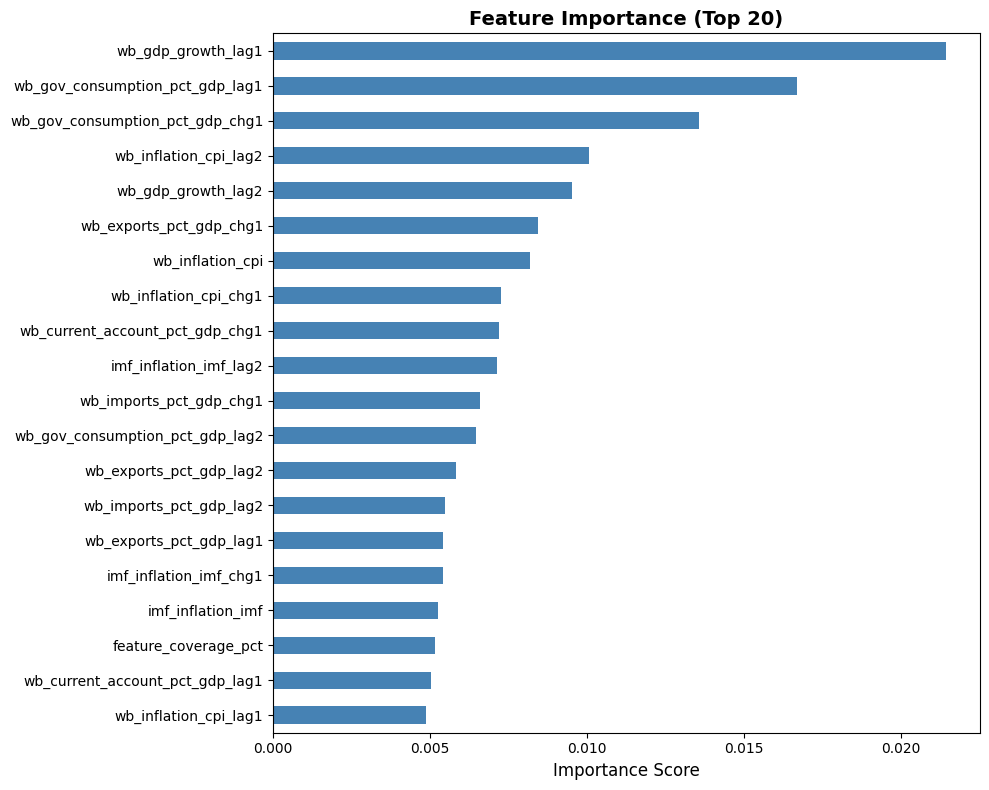

In [42]:
# Option 2: Just show top 20 features (keeps country dummies if they rank highly)
# importance_df_clean = importance_df.head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

importance_df_clean.head(20).sort_values("importance").plot.barh(
    x="feature", y="importance", ax=ax, color="steelblue", legend=False
)

ax.set_title("Feature Importance (Top 20)", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.show()

## Classification

In [38]:
world_bank.columns

Index(['country', 'year', 'wb_current_account_pct_gdp', 'wb_exports_pct_gdp',
       'wb_gdp_growth', 'wb_gov_consumption_pct_gdp', 'wb_imports_pct_gdp',
       'wb_inflation_cpi', 'imf_inflation_imf', 'non_null_feature_count',
       'feature_coverage_pct', 'wb_current_account_pct_gdp_lag1',
       'wb_current_account_pct_gdp_lag2', 'wb_exports_pct_gdp_lag1',
       'wb_exports_pct_gdp_lag2', 'wb_gdp_growth_lag1', 'wb_gdp_growth_lag2',
       'wb_gov_consumption_pct_gdp_lag1', 'wb_gov_consumption_pct_gdp_lag2',
       'wb_imports_pct_gdp_lag1', 'wb_imports_pct_gdp_lag2',
       'wb_inflation_cpi_lag1', 'wb_inflation_cpi_lag2',
       'imf_inflation_imf_lag1', 'imf_inflation_imf_lag2',
       'wb_current_account_pct_gdp_chg1', 'wb_exports_pct_gdp_chg1',
       'wb_gdp_growth_chg1', 'wb_gov_consumption_pct_gdp_chg1',
       'wb_imports_pct_gdp_chg1', 'wb_inflation_cpi_chg1',
       'imf_inflation_imf_chg1', 'recession'],
      dtype='str')

In [ ]:
y = world_bank["recession"]
X = world_bank.drop(columns=["recession", "year"])
X = pd.get_dummies(X, columns=["country"], drop_first=True)

# Val-test split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

# Train-val split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=123
)

In [44]:
xgb_mod_class = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=123,
    eval_metrics="binary:logistic",
)

xgb_mod_class.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = xgb_mod_class.predict(X_test)
y_prob = xgb_mod_class.predict_proba(X_test)[:, 1]

acc_score = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {acc_score: .4f}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

auc_roc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC Score: {auc_roc: .4f}")

brier = brier_score_loss(y_test, y_prob)
print(f"Brier Score: {brier: .4f}")

cl_loss = log_loss(y_test, y_prob)
print(f"Cross-Entropy Loss: {cl_loss: .4f}")

/Users/gauravlaw/Desktop/Machine Learning/SP26_IDS705_ML_Project/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:30:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy Score:  0.9556
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2393
           1       0.78      0.35      0.48       150

    accuracy                           0.96      2543
   macro avg       0.87      0.67      0.73      2543
weighted avg       0.95      0.96      0.95      2543

[[2378   15]
 [  98   52]]
AUC-ROC Score:  0.9266
Brier Score:  0.0353
Cross-Entropy Loss:  0.1334


In [45]:
# Get feature importances
importance_df = pd.DataFrame(
    {
        "feature": xgb_mod_class.get_booster().feature_names,
        "importance": xgb_mod_class.feature_importances_,
    }
).sort_values("importance", ascending=False)

# Option 1: Drop country dummies entirely, keep only real features
importance_df_clean = importance_df[
    ~importance_df["feature"].str.startswith("country_")
]

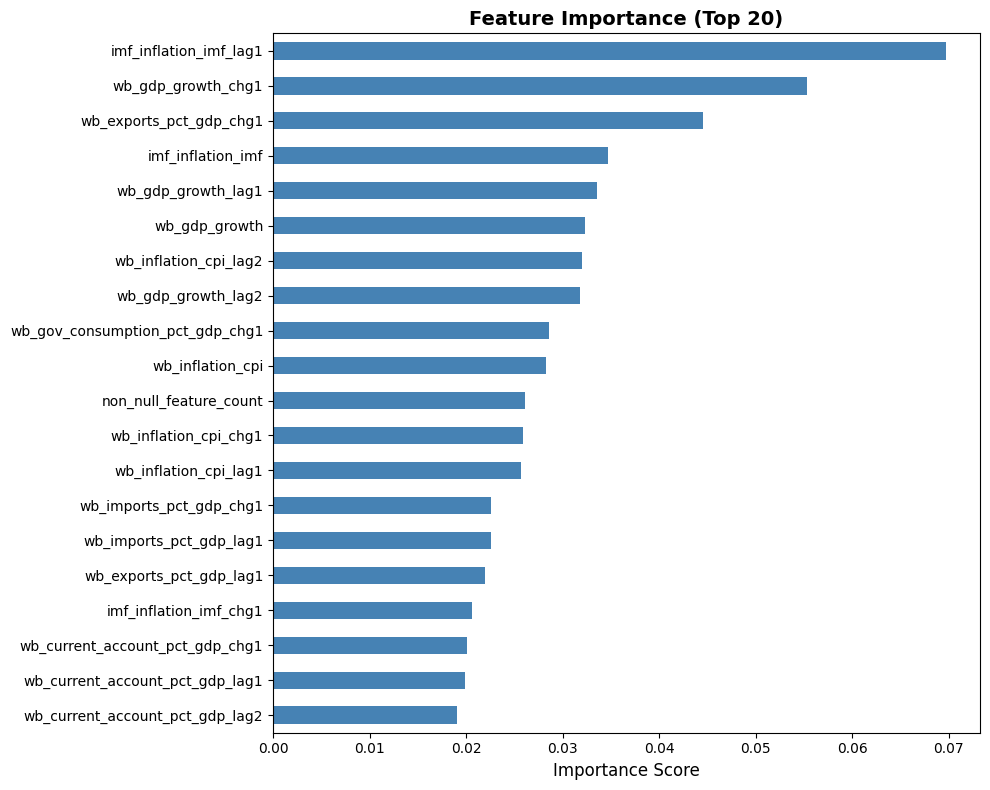

In [46]:
# Option 2: Just show top 20 features (keeps country dummies if they rank highly)
# importance_df_clean = importance_df.head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

importance_df_clean.head(20).sort_values("importance").plot.barh(
    x="feature", y="importance", ax=ax, color="steelblue", legend=False
)

ax.set_title("Feature Importance (Top 20)", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.show()